In [15]:
import itertools
import matplotlib.pyplot as plt

# Problem setting

Consider a board that is an infinite 2D Carthesian grid.  Positions on the grid can be labeled $(x, y)$, with $x, y \in \mathbb{Z}$.

At any given time, exactly three board positions are taken.  The starting configuration is
$$
    (0, 0), (1, 0), (0, 1)
$$
In each step, a point can "hop" over another point, while the other two remain in place.  For instance, the first point can hop over the second, leading to
$$
    (2, 0), (1, 0), (0, 1)
$$
Hops can be in any direction, so, starting from the initial configuration again, the third point might hop over the second, leaning to
$$
    (0, 0), (1, 0), (2, -1)
$$

The question: can the following configuration be reached?
$$
    (1, 0), (0, 1), (1, 1)
$$

If so, in how many steps, if not prove it.

# Enumeration

The new position of a point $p$ that hops over a point $p_\mathrm{fixed}$ can be computed as follows.

In [2]:
def move(p_fixed, p):
    return (2*p_fixed[0] - p[0], 2*p_fixed[1] - p[1])

Given a configuration, the following function returns the set of all configurations that can be reached.

In [3]:
def moves(positions):
    new_positions = set()
    for i1, i2 in itertools.combinations(range(3), 2):
        new_positions.add(tuple(sorted((positions[i1], move(positions[i1], positions[i2]), positions[3 - i1 - i2]))))
        new_positions.add(tuple(sorted((positions[i2], move(positions[i2], positions[i1]), positions[3 - i1 - i2]))))
    return new_positions

Starting from a set of initial configurations, the following function computes the set of all configurations that can be reached in a given number of steps.

In [8]:
def do_steps(max_steps):
    all_positions = {tuple(sorted(((0, 0), (1, 0), (0, 1),)))}
    goal = tuple(sorted(((0, 1), (1, 0), (1, 1))))
    for step in range(1, max_steps + 1):
        current_positions = all_positions.copy()
        for positions in current_positions:
            all_positions |= moves(positions)
        if goal in all_positions:
            print(f'goal reached in {steps} steps')
            break
    else:
        print(f'goal not reached in {max_steps} steps')
    return all_positions

To test the functions, consider the starting configuration and compute all configurations that can be reached from it.

In [9]:
positions = (
    (0, 0),
    (1, 0),
    (0, 1),
)

In [10]:
moves(positions)

{((-1, 0), (0, 0), (0, 1)),
 ((-1, 2), (0, 0), (0, 1)),
 ((0, -1), (0, 0), (1, 0)),
 ((0, 0), (1, 0), (2, -1)),
 ((0, 1), (0, 2), (1, 0)),
 ((0, 1), (1, 0), (2, 0))}

In [13]:
all_positions = do_steps(10)

goal not reached in 10 steps


In [14]:
len(all_positions)

468856

In [16]:
x_coords = []
y_coords = []
for x, y in itertools.chain.from_iterable(all_positions):
    x_coords.append(x)
    y_coords.append(y)

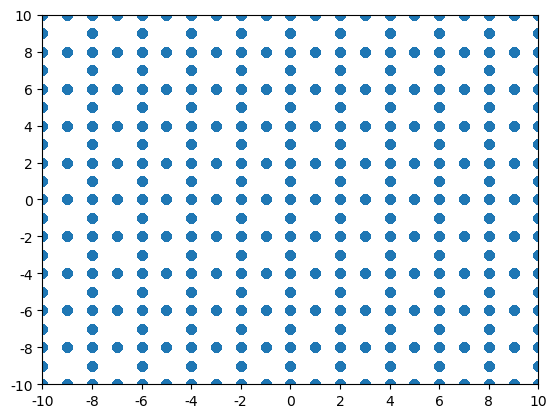

In [20]:
plt.plot(x_coords, y_coords, 'o')
plt.xlim([-10, 10])
plt.xticks(range(-10, 11, 2), (str(x) for x in range(-10, 11, 2)))
plt.ylim([-10, 10])
plt.yticks(range(-10, 11, 2), (str(x) for x in range(-10, 11, 2)));